<a href="https://colab.research.google.com/github/shown5/Hands-on-Generative-AI/blob/main/chap4_diffusionModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

４章 拡散モデル

本章ではテキストで内容を指示するだけで画像を生成できるモデルの仕組みを掘り下げていく。

拡散モデルの基本的な考え方は、ノイズを加えて劣化させた画像を受け取り、そのノイズを取り除いて元の鮮明な画像に復元すること。

In [7]:
%pip install genaibook

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.2 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
  Attempting uninstall: huggingface_hub
    Found exi

4.1 重要な着想：反復的精緻化

拡散モデルを強力にしている要素は、GAN や VAE が最終出力を１発勝負で出力するのに対して、拡散モデルは他段階の反復を経て出力を生成する。この反復的精緻化（iterative refinement）のおかげで徐々に出力の質を高めていくことができる。


Hugging face の diffuser ライブラリを使えば事前訓練済みの拡散モデルを簡単にロードできる。ここでは初期の拡散モデルの一つである ddpm-celebahq-256 のデータセットを使って、これににた画像を生成する。

In [4]:
import torch
from diffusers import DDPMPipeline

from genaibook.core import get_device

# GPU と CPU のどっちを使うかを設定する
device = get_device()

# パイプラインを読み込む
image_pipe = DDPMPipeline.from_pretrained("google/ddpm-celebahq-256")
image_pipe.to(device)

# 画像をサンプリングする
# image_pipe().images[0]

/usr/local/lib/python3.12/dist-packages/diffusers/models/transformers/transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
/usr/local/lib/python3.12/dist-packages/diffusers/models/transformers/transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/790 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

diffusion_pytorch_model.bin:   0%|          | 0.00/455M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


DDPMPipeline {
  "_class_name": "DDPMPipeline",
  "_diffusers_version": "0.36.0",
  "_name_or_path": "google/ddpm-celebahq-256",
  "scheduler": [
    "diffusers",
    "DDPMScheduler"
  ],
  "unet": [
    "diffusers",
    "UNet2DModel"
  ]
}

コードを実行すると、画像生成までに１０００ステップも要していることがわかる。
これが拡散モデルの欠点の一つ。
このサンプリングプロセスをステップごとに再現すれば、内部で何が起きているのかをより深く理解できる。

拡散プロセスの開始時、サンプルxを４枚分のランダム画像で初期化して、ここから３０ステップかけて入力画像のノイズを除去し、最終的に実データの画像に近づけていく。

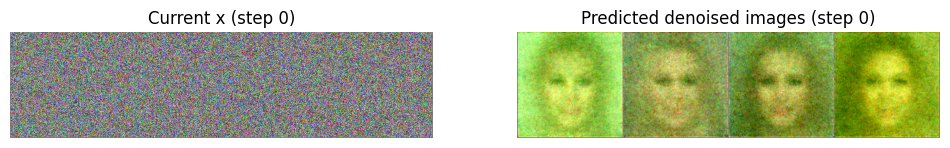

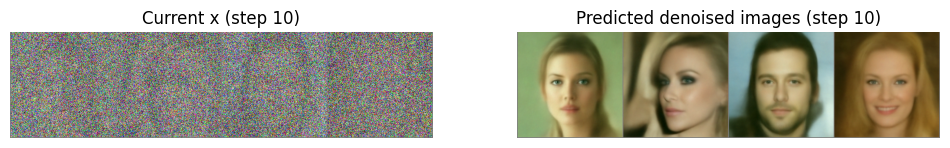

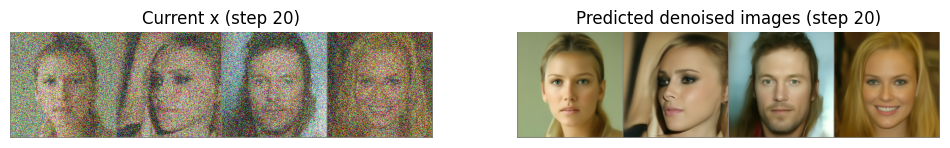

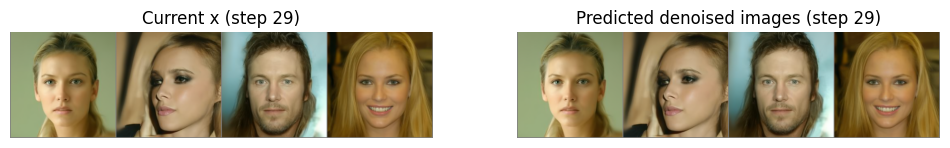

In [ ]:
from genaibook.core import plot_noise_and_denoise

# ランダムな初期値として４枚の画像バッチを用いる
# 各画像は３チャネル（RGB）、256*256ピクセルの画像
image = torch.randn(4, 3, 256, 256).to(device)

# 拡散ステップ数を指定する
image_pipe.scheduler.set_timesteps(num_inference_steps=30)

# サンプリングのタイムステップを繰り返す
for i, t in enumerate(image_pipe.scheduler.timesteps):
  with torch.inference_mode():
    noise_pred = image_pipe.unet(image, t)["sample"]

    scheduler_output = image_pipe.scheduler.step(noise_pred, t, image)

    image = scheduler_output.prev_sample

    if i % 10 == 0 or i == len(image_pipe.scheduler.timesteps) - 1:
      plot_noise_and_denoise(scheduler_output, i)

4.2 拡散モデルの訓練

拡散モデルをゼロから訓練することで仕組みをより深く理解することを目指す。
diffusers ライブラリのコンポーネントを利用する。

以下の手順を繰り返してモデルを訓練する。
1. 訓練用データからいくつかの画像を読み込む
2. ノイズを加える ※ノイズにも多様性が必要
3. ノイズを加えた画像をモデルに与える
4. モデルがどれだけノイズを除去できたかを評価する
5. この情報を使ってモデルの重みを更新する

4.2.1 データ

今回は HuggingFace にある蝶のデータセットを使う。

In [5]:
from datasets import load_dataset

dataset = load_dataset("huggan/smithsonian_butterflies_subset", split="train")

Repo card metadata block was not found. Setting CardData to empty.


次の手順で訓練に適した形に処理する。

1. 固定サイズにリサイズする
2. ランダムに反転させデータオーグメンテーションを行う
3. 画像をテンソルに変換する
4. 平均０、値が-1から1の間になるように正規化する

In [6]:
from torchvision import transforms

image_size=64

# 変換を定義する
preprocess=transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

In [7]:
def transform(examples):
  examples = [preprocess(image) for image in examples["image"]]
  return {"images": examples}


dataset.set_transform(transform)
batch_size=16

train_dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True
)

バッチをロードして実際の画像を確認してみる。

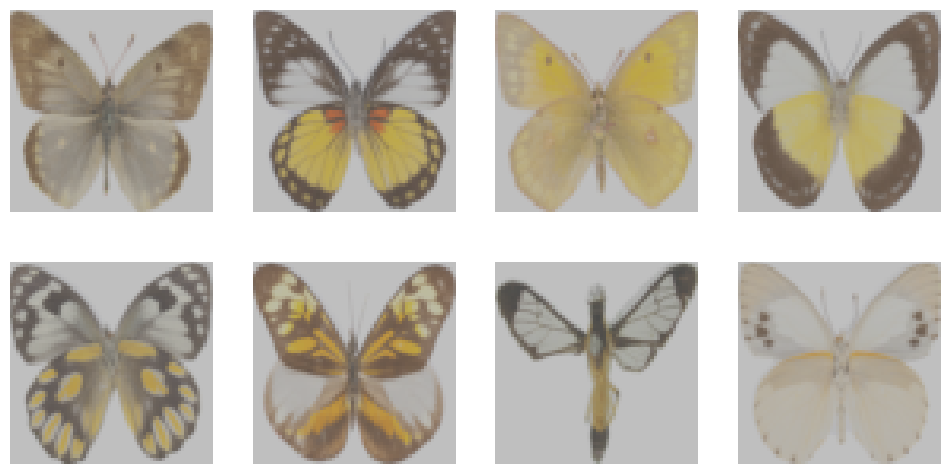

In [8]:
from genaibook.core import show_images

batch = next(iter(train_dataloader))
images = batch["images"]
show_images(images[:8]*0.5*0.5+0.5)

In [ ]:
4.2.2 ノイズの付加

データにノイズを加えるにあたり、ノイズの量はノイズスケジュールというものによって制御される。
ノイズスケジュールの方法は様々あるが、ここでは DDPM の論文に基づく一般的な手法を実際に試してみる。

diffuser ライブラリでは Scheduler というクラスによってノイズの付加が管理される。

In [1]:
from diffusers import DDPMScheduler

# beta_start と beta_end については次節で説明する
scheduler = DDPMScheduler(
    num_train_timesteps=1000, beta_start=0.001, beta_end=0.02
)

# 0から999までを等間隔で８分割した値からあるテンソルを作成する
timesteps = torch.linspace(0, 999, 8).long()

# データセットから８枚の画像を読みOK身それぞれにノイズを徐々に加えていく
x = batch["images"][:8]
noise = torch.rand_like(x)
noised_x = scheduler.add_noise(x, noise, timesteps)
show_images((noised_x * 0.5 * 0.5).clip(0, 1))

NameError: name 'torch' is not defined

4.2.3 UNet